# 1. Data Preparation

In [1]:
import pandas as pd
df = pd.read_csv("../data/q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = df
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

Importance of Scaling before applying K-Means

All features are scaled using StandardScaler before applying K-Means. This is important because K-Means uses distance to form clusters, and features with larger values can dominate the results. By scaling, all features are brought to the same range, ensuring each feature contributes equally to the clustering process.

# 2. Choosing K — Elbow Method

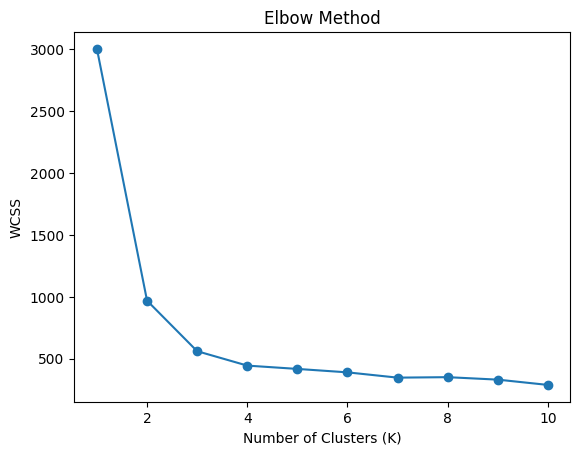

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Optimal K is 3

Justification

From the elbow plot, there is a sharp decrease in WCSS from K = 1 to K = 3, which indicates that adding clusters significantly improves the grouping. After K = 3, the decrease in WCSS becomes much slower, meaning additional clusters do not provide much improvement. Therefore, K = 3 is chosen as the optimal number of clusters as it provides a good balance between simplicity and performance.

# 3. K-Means Clustering

Fit K-Means for K=3

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x_scaled)
print(kmeans)

KMeans(n_clusters=3, random_state=42)


Adding Cluster Column to the Dataframe

In [5]:
df['Cluster'] = kmeans.labels_

Print the Cluster Centroids

In [6]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=x_scaled.columns)
print(centroids)

        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.132214      1.235574         -1.106680     1.253260   
2 -0.004449     -0.168055         -0.041370    -0.290670   

   days_since_last_visit  num_categories_purchased  
0              -0.813494                 -1.045346  
1               1.125725                  1.172991  
2              -0.287579                 -0.095968  


Interpretation of Clusters

Cluster 0 represents young customers who visit frequently but spend less. They usually have smaller basket sizes and purchase fewer categories. These customers can be targeted with offers to increase their spending.

Cluster 1 represents older customers who spend more but visit less often. They have larger basket sizes and purchase more categories. These are high-value customers and should be retained with loyalty programs.

Cluster 2 represents middle-aged customers with moderate spending and average visit frequency. Their basket size and category purchases are also moderate. These customers have potential to be converted into high-value customers.

# 4. Dimensionality Reduction with PCA

Reduce Data to Two Principal Components using PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

Print the explained variance ratio for each component

In [8]:
print(pca.explained_variance_ratio_)

[0.83560354 0.05568764]


Feature Loadings

In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=x_scaled.columns,
    index=['PC1', 'PC2']
)

print(loadings)

          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


Interpretation of PC1 and PC2

PC1 shows overall customer behavior. It combines features like spending, visits, and basket size, so it tells whether a customer is generally high or low activity.

PC2 mainly shows how recently a customer visited. It helps separate customers who visited recently from those who have not visited for a long time.

# 5. Cluster Visualisation

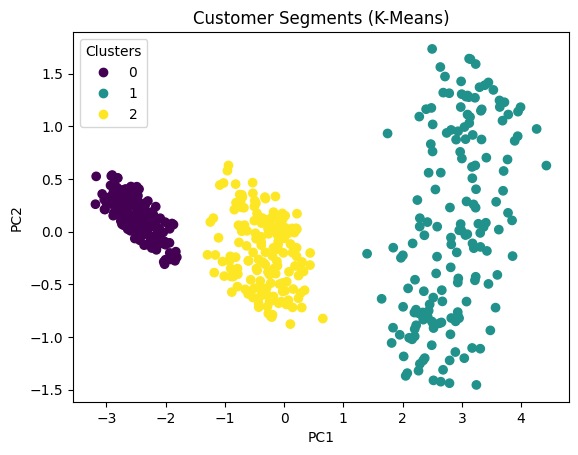

In [10]:
pca_df = pd.DataFrame(x_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans.labels_
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (K-Means)')

plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()